# 🚢 Machine Learning Classification with the Titanic

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SharifiZarchi/IntroAI/blob/main/Session_05/Titanic/Titanic_Classification_Tutorial_EN.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2FSharifiZarchi%2FIntroAI%2Fblob%2Fmain%2FSession_05%2FTitanic%2FTitanic_Classification_Tutorial_EN.ipynb)

On the night of April 15, 1912, the Titanic — "the unsinkable ship" — hit an iceberg. Of the roughly 2,200 people on board, more than 1,500 died. There were not enough lifeboats for everyone… so **who got a seat?**

That question became the most famous beginner competition on [Kaggle](https://www.kaggle.com/competitions/titanic): given a passenger's information (age, sex, ticket class, …), predict whether they survived. Today we solve it, step by step, and climb from a naive guess all the way to a solution worthy of the top of the leaderboard.

Last session we predicted a **number** (house prices) — that was **regression**. Today we predict a **category** (survived / died) — that is **classification**. Same recipe: load → look → clean → plot → model → evaluate.

**How to run:** click a grey cell and press `Shift + Enter`. Run cells in order, top to bottom. Each part ends with a small ✏️ exercise — try it before opening the solution!

Data from [Kaggle](https://www.kaggle.com/competitions/titanic), saved next to this file as `titanic.csv`.

---
# Part 1 — Warm-up: predicting a category

In the last notebook we met variables, lists, loops, and functions. (New here? Do Part 1 of the Session 4 notebook first — it takes five minutes.)

One Python block is still missing, and it happens to be the seed of today's main idea: `if / else` — **making a decision**.

### 1.1 `if / else` — the computer makes a choice
The computer checks a condition; if it is true it runs one block, otherwise another. Note the `:` and the indentation.

In [1]:
age = 8

if age < 18:
    print("child")
else:
    print("adult")

child


### 1.2 A classifier written by hand
A **classifier** is just a function that takes features in and gives a category out. Here is a one-rule classifier for the Titanic. Keep it in mind — we will meet it again.

In [2]:
def guess_survival(sex):
    if sex == "female":
        return 1     # survives
    else:
        return 0     # does not survive

print(guess_survival("female"))
print(guess_survival("male"))

1
0


### 1.3 Libraries
The same four friends as last time.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

print("Libraries ready ✅")

Libraries ready ✅


### ✏️ Exercise 1
Change the code below so it prints three groups: `"child"` for under 13, `"teenager"` for 13 to 17, and `"adult"` for 18 and above. (Hint: `elif` means "else, if…")

In [4]:
age = 15

# ✏️ Your turn — add an elif for teenagers
if age < 13:
    print("child")
else:
    print("adult")

adult


<details>
<summary>💡 Solution — click to open</summary>

```python
age = 15

if age < 13:
    print("child")
elif age < 18:
    print("teenager")
else:
    print("adult")
```

</details>

---
# Part 2 — Load the data

One row per passenger, one column per piece of information.

In [5]:
# The file sits next to this notebook; if it is not found (e.g. on Google Colab),
# we read the exact same file from the course's GitHub page.
url = "https://raw.githubusercontent.com/SharifiZarchi/IntroAI/main/Session_05/Titanic/titanic.csv"
try:
    df = pd.read_csv("titanic.csv")
except FileNotFoundError:
    df = pd.read_csv(url)

print("Our table has", df.shape[0], "rows and", df.shape[1], "columns")

Our table has 891 rows and 12 columns


See the first few rows with `.head()`:

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


What each column means:

| Column | Meaning |
|---|---|
| `Survived` | **the label we want to predict**: 1 = survived, 0 = died |
| `Pclass` | ticket class: 1 = first (expensive), 2 = middle, 3 = third (cheap) |
| `Name`, `Sex`, `Age` | name, sex, age |
| `SibSp` | number of siblings + spouses on board |
| `Parch` | number of parents + children on board |
| `Ticket`, `Fare` | ticket number and ticket price |
| `Cabin` | cabin number (if known) |
| `Embarked` | boarding port: S = Southampton, C = Cherbourg, Q = Queenstown |

In Session 3 language: `Survived` is the **label**, everything else is a **feature**.

### ✏️ Exercise 2
`.head()` shows the first rows; `.tail()` shows the last ones. Show the last 5 passengers of the table.

In [7]:
# ✏️ Your turn



<details>
<summary>💡 Solution — click to open</summary>

```python
df.tail()
```

</details>

---
# Part 3 — Look at the data

Same three commands as last time: `.info()`, `.describe()`, `.value_counts()`.

### 3.1 `.info()` — column types and missing values

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


The table has 891 rows, but `Age` has only 714 values — the age of 177 passengers is unknown. `Cabin` is almost empty (687 missing!) and `Embarked` misses 2. Real data is never complete; we deal with this in Part 5.

### 3.2 `.describe()` — quick stats

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Read the `mean` row: the average of `Survived` is about 0.38 — **only 38% survived**. The average age is about 30, and ticket prices run from 0 to a spectacular 512 pounds.

### 3.3 `.value_counts()` — count categories

In [10]:
print("Survived?")
print(df["Survived"].value_counts())

print("\nSex:")
print(df["Sex"].value_counts())

print("\nTicket class:")
print(df["Pclass"].value_counts())

Survived?
Survived
0    549
1    342
Name: count, dtype: int64

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Ticket class:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


549 died, 342 survived. Most passengers were men, and most travelled third class. Remember these numbers — they set the stage.

### ✏️ Exercise 3
How many passengers boarded at each port? Use `.value_counts()` on the `Embarked` column.

In [11]:
# ✏️ Your turn



<details>
<summary>💡 Solution — click to open</summary>

```python
print(df["Embarked"].value_counts())
# S (Southampton) 644, C (Cherbourg) 168, Q (Queenstown) 77
```

</details>

---
# Part 4 — Insight: see the answer before modeling

This is the most important part of the notebook. Before any model, we ask the data: **who survived?** Every pattern we spot here is something a good model should also find — so when we build models later, we can check whether they "understood" the data.

### 4.1 Survival by sex
`.groupby("Sex")` splits the passengers into groups, and `.mean()` of a 0/1 column is exactly the **survival rate**.

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


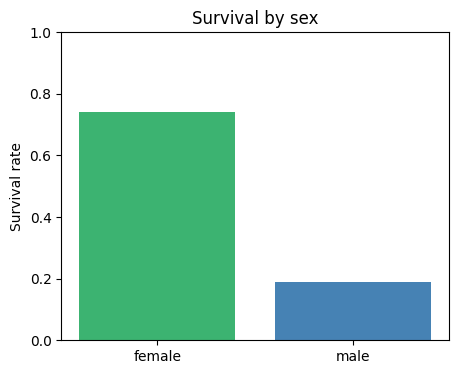

In [12]:
rate_by_sex = df.groupby("Sex")["Survived"].mean()
print(rate_by_sex)

plt.figure(figsize=(5, 4))
plt.bar(["female", "male"], rate_by_sex[["female", "male"]], color=["mediumseagreen", "steelblue"])
plt.ylabel("Survival rate")
plt.title("Survival by sex")
plt.ylim(0, 1)
plt.show()

A huge gap: **74% of women survived, versus 19% of men.** "Women and children first" was not just a saying — it is right here in the data, a century later. This single fact is the strongest signal in the whole dataset.

### 4.2 Survival by ticket class

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


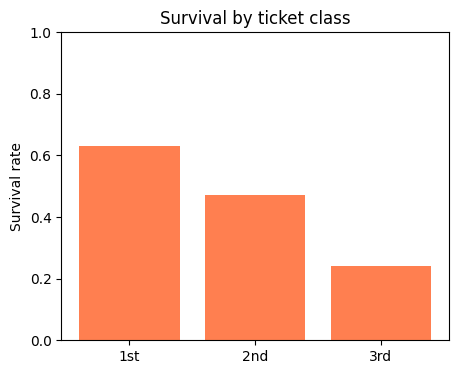

In [13]:
rate_by_class = df.groupby("Pclass")["Survived"].mean()
print(rate_by_class)

plt.figure(figsize=(5, 4))
plt.bar(["1st", "2nd", "3rd"], rate_by_class[[1, 2, 3]], color="coral")
plt.ylabel("Survival rate")
plt.title("Survival by ticket class")
plt.ylim(0, 1)
plt.show()

First class 63%, second 47%, third 24%. The lifeboats were on the upper decks, next to the expensive cabins. Money mattered.

### 4.3 And the children?
Two overlapping histograms: ages of those who survived (green) and those who died (grey).

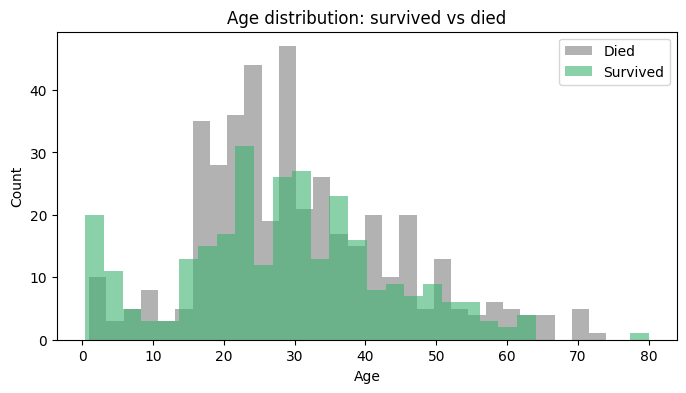

Survival rate of children under 10: 0.61
Survival rate of everyone:          0.38


In [14]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Survived"] == 0]["Age"].dropna(), bins=30, alpha=0.6, color="gray", label="Died")
plt.hist(df[df["Survived"] == 1]["Age"].dropna(), bins=30, alpha=0.6, color="mediumseagreen", label="Survived")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age distribution: survived vs died")
plt.legend()
plt.show()

print("Survival rate of children under 10:", round(df[df["Age"] < 10]["Survived"].mean(), 2))
print("Survival rate of everyone:         ", round(df["Survived"].mean(), 2))

Look at the far left of the chart: for young children the green bars beat the grey ones — **61% of children under 10 survived**, versus 38% overall. The "children" part of "women and children first" checks out too.

### 4.4 Sex and class together
The two strongest signals combined in one picture.

Sex     female  male
Pclass              
1         0.97  0.37
2         0.92  0.16
3         0.50  0.14


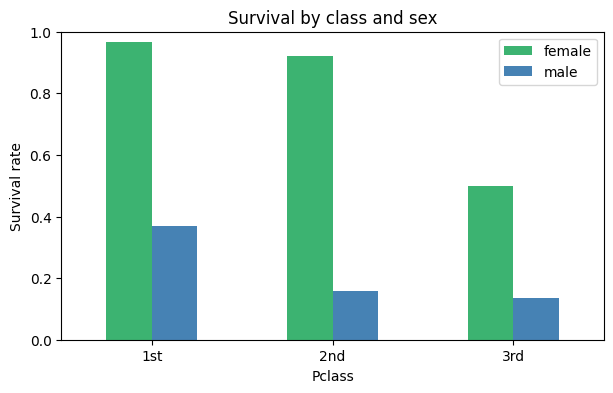

In [15]:
table = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
print(table.round(2))

table.plot(kind="bar", figsize=(7, 4), color=["mediumseagreen", "steelblue"])
plt.ylabel("Survival rate")
plt.title("Survival by class and sex")
plt.xticks([0, 1, 2], ["1st", "2nd", "3rd"], rotation=0)
plt.ylim(0, 1)
plt.legend(["female", "male"])
plt.show()

The extremes are stunning: a first-class woman survived with **97%** probability; a third-class man with **13%**. Between these two passengers lies the whole story of the Titanic — and everything our models are about to learn.

### 4.5 What a classification problem looks like
One last picture, the most important one conceptually. Each dot is a passenger: age on one axis, fare on the other. Green = survived, grey = died.

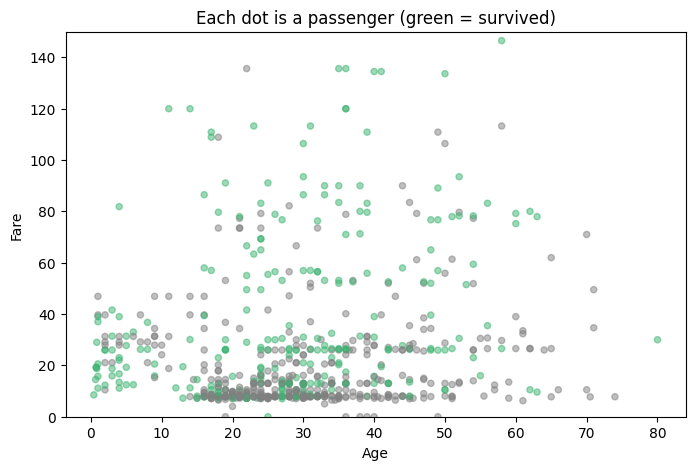

In [16]:
plt.figure(figsize=(8, 5))
colors = df["Survived"].map({0: "gray", 1: "mediumseagreen"})
plt.scatter(df["Age"], df["Fare"], c=colors, alpha=0.5, s=20)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.ylim(0, 150)   # a few very expensive tickets are cut off so we can see the rest
plt.title("Each dot is a passenger (green = survived)")
plt.show()

**This picture *is* classification.** A classifier's entire job: given a new dot's position, guess its color. You can see a tendency — green gathers at high fares and young ages — but the colors are mixed, and no single straight line can separate them. That is exactly why we need models smarter than a ruler.

(Remember the alien-classification slide from Session 2? Same picture, real data.)

### ✏️ Exercise 4
Draw the survival rate by boarding port (`Embarked`) as a bar chart, like we did for sex. Which port had the luckiest passengers? Any guess why? (Hint from 4.2: think about ticket class.)

In [17]:
# ✏️ Your turn
# rate_by_port = df.groupby(...)[...].mean()



<details>
<summary>💡 Solution — click to open</summary>

```python
rate_by_port = df.groupby("Embarked")["Survived"].mean()
print(rate_by_port)

plt.figure(figsize=(5, 4))
plt.bar(["C", "Q", "S"], rate_by_port[["C", "Q", "S"]], color="mediumpurple")
plt.ylabel("Survival rate")
plt.title("Survival by boarding port")
plt.show()
```

Cherbourg (55%) beats Queenstown (39%) and Southampton (34%) — mostly because many first-class passengers boarded at Cherbourg. The port itself did not save anyone; it is a hidden echo of ticket class!

</details>